# **Dataset de Mantenimiento Predictivo**

Importar librerias y cargar el dataset de prueba de trabajo

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
import pandas as pd
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("umerrtx/machine-failure-prediction-using-sensor-data")

print("Path to dataset files:", path)

# Construct the full path to the data.csv file
file_path = os.path.join(path, 'data.csv')

# Read the CSV file into a pandas DataFrame
df = pd.read_csv(file_path)

100%|██████████| 6.79k/6.79k [00:00<00:00, 11.7MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/umerrtx/machine-failure-prediction-using-sensor-data/versions/1


In [3]:
import os

download_path = '/root/.cache/kagglehub/datasets/umerrtx/machine-failure-prediction-using-sensor-data/versions/1'
print("Contents of the downloaded directory:")
for item in os.listdir(download_path):
    print(item)

Contents of the downloaded directory:
data.csv


In [4]:
# The data is already loaded into the DataFrame 'df' in a previous cell.
df_2 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Archivos CSV/predictive_maintenance_dataset.csv')

Visualizar los datos del dataframe

# **Monitoreo de datos atmosféricos**

In [5]:
df

,footfall,tempMode,AQ,USS,CS,VOC,RP,IP,Temperature,fail
0,0,7,7,1,6,6,36,3,1,1
1,190,1,3,3,5,1,20,4,1,0
2,31,7,2,2,6,1,24,6,1,0
3,83,4,3,4,5,1,28,6,1,0
4,640,7,5,6,4,0,68,6,1,0
...,...,...,...,...,...,...,...,...,...,...
939,0,7,7,1,6,4,73,6,24,1
940,0,7,5,2,6,6,50,6,24,1
941,0,3,6,2,7,5,43,6,24,1
942,0,6,6,2,5,6,46,7,24,1


* footfall -> Personas u actividad humana cerca
* tempMode -> Sensación de temperatura térmica
* AQ (Air Quality) -> Calidad del aire
* USS -> Ultra Sonic Sensor Digital
* Current Sensor -> Sensor de corriente eléctrica
* VOC (Volatile Organic Compound) -> Compuestos del aire
* RP (Rotational Power) -> Velocidad de rotación
* IP (Input Power)
* Temperature (Temperatura operativa de las máquinas)
* Fail (Indicador de falla en el sistema)

## **Monitoreo de métricas y fallas**

In [6]:
df_2

,date,device,failure,metric1,metric2,metric3,metric4,metric5,metric6,metric7,metric8,metric9
0,1/1/2015,S1F01085,0,215630672,55,0,52,6,407438,0,0,7
1,1/1/2015,S1F0166B,0,61370680,0,3,0,6,403174,0,0,0
2,1/1/2015,S1F01E6Y,0,173295968,0,0,0,12,237394,0,0,0
3,1/1/2015,S1F01JE0,0,79694024,0,0,0,6,410186,0,0,0
4,1/1/2015,S1F01R2B,0,135970480,0,0,0,15,313173,0,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...
124489,11/2/2015,Z1F0MA1S,0,18310224,0,0,0,10,353705,8,8,0
124490,11/2/2015,Z1F0Q8RT,0,172556680,96,107,4,11,332792,0,0,13
124491,11/2/2015,Z1F0QK05,0,19029120,4832,0,0,11,350410,0,0,0
124492,11/2/2015,Z1F0QL3N,0,226953408,0,0,0,12,358980,0,0,0


Este dataset describe la fecha y el dispositivo que falló, describiendo las métricas.

# **Análisis exploratorio de datos**

## Identificar los dispositivos que fallan más

/tmp/ipython-input-2899639835.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=failures_per_device.index, y=failures_per_device.values, palette="Reds_r")


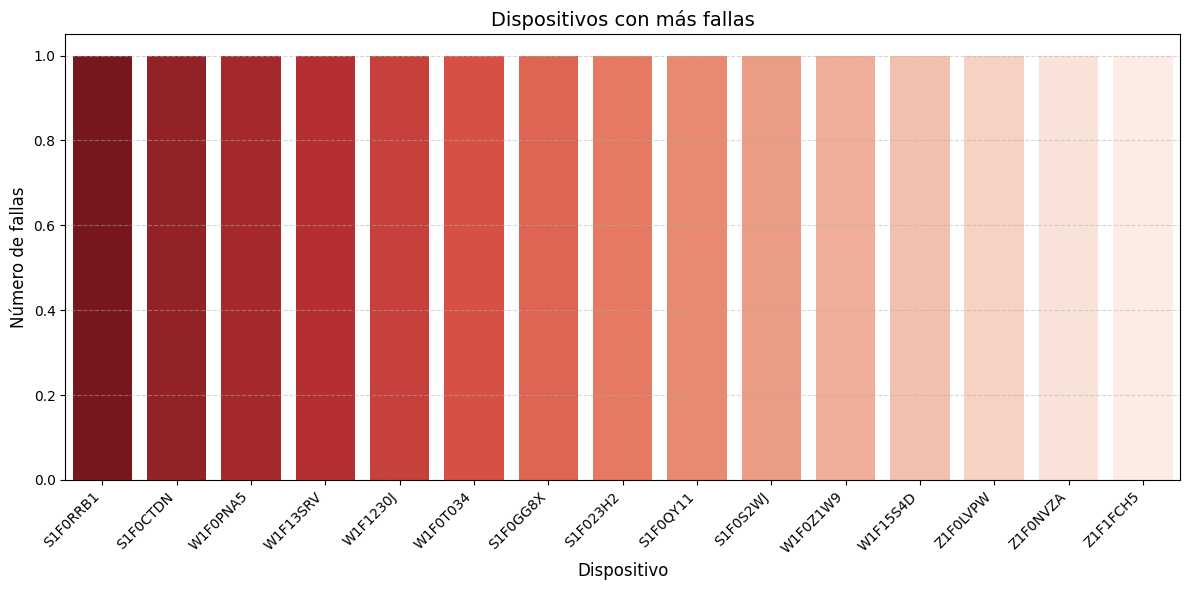

📊 9.07% de los dispositivos han presentado al menos una falla.


In [7]:
# Contar número de fallas por dispositivo
failures_per_device = df_2[df_2['failure'] == 1]['device'].value_counts().head(15)

plt.figure(figsize=(12,6))
sns.barplot(x=failures_per_device.index, y=failures_per_device.values, palette="Reds_r")
plt.title("Dispositivos con más fallas", fontsize=14)
plt.xlabel("Dispositivo", fontsize=12)
plt.ylabel("Número de fallas", fontsize=12)
plt.xticks(rotation=45, ha='right')  # Rotar nombres para mejor lectura
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Porcentaje de dispositivos con al menos una falla
failure_rate = df_2.groupby('device')['failure'].max().mean() * 100
print(f"📊 {failure_rate:.2f}% de los dispositivos han presentado al menos una falla.")


Los dispositivos con más fallas son S1F0RRB1, S1F0CTDN Y W1F0WPNA.


## **Relación entre fallos de los dispositivos y condiciones atmósfericas**

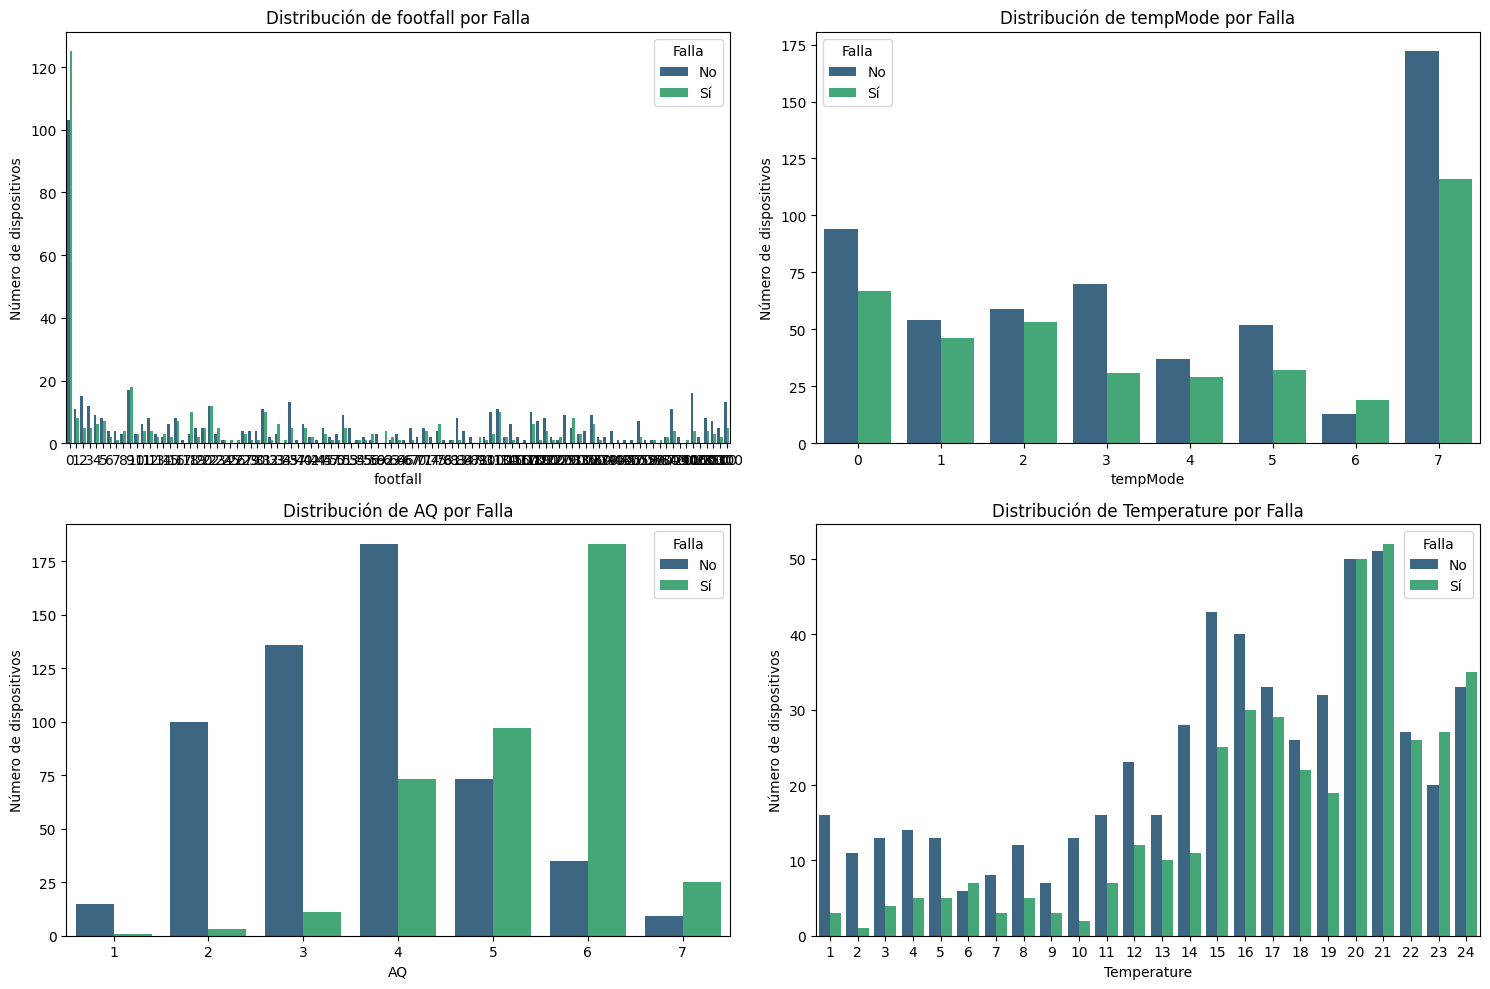

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

atmospheric_cols = ['footfall', 'tempMode', 'AQ', 'Temperature']

for i, col in enumerate(atmospheric_cols):
    sns.countplot(x=col, hue='fail', data=df, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Distribución de {col} por Falla')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Número de dispositivos')
    axes[i].legend(title='Falla', labels=['No', 'Sí'])

plt.tight_layout()
plt.show()

Insights
- Las fallas no presentan un patron claro ante el factor del tempomode, esto quiere decir que es posible que no influya mucho. Puesto que aunque el tempmode no es 7 no se dan muchas fallas.
- Cuando la temperatura es 21° fallan más dispositivos esto puede indicar que el sobrecalentamiento puede estar relacionado con la caída del sistema.
- La calidad del aire presenta una influencia significativa en los fallos, puesto que cuando el valor de esta es 6 se registra una cantidad de fallos considerable. Y aunque hay pocos datos para cuando la calidad del aire es 7 este sigue siendo más alto en comparación con los valores normales.


## **Relación de los fallos por condiciones de la máquina**

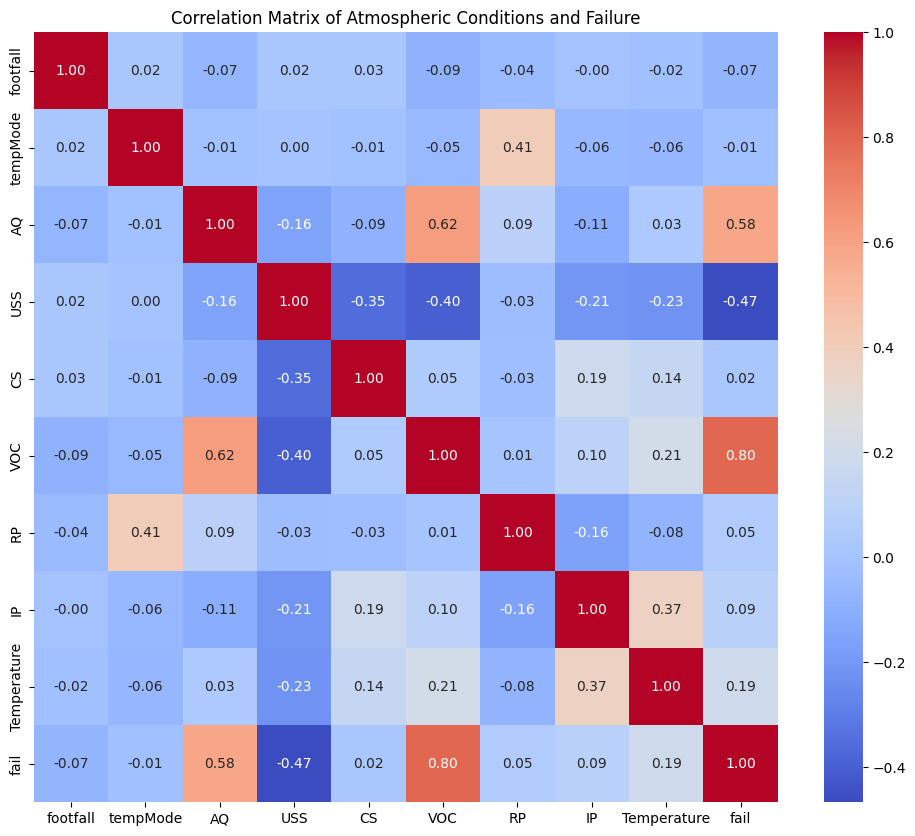

In [9]:
# Select only numerical columns for correlation calculation
numerical_df = df.select_dtypes(include=np.number)

# Calculate the correlation matrix
correlation_matrix_df = numerical_df.corr()

# Visualize the correlation matrix as a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_df, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Atmospheric Conditions and Failure')
plt.show()

- El VOC es la variable más relacionada con las fallas en el sistema (Compuestos Volatiles del Aire)
- Seguido por la calidad del aire AQ

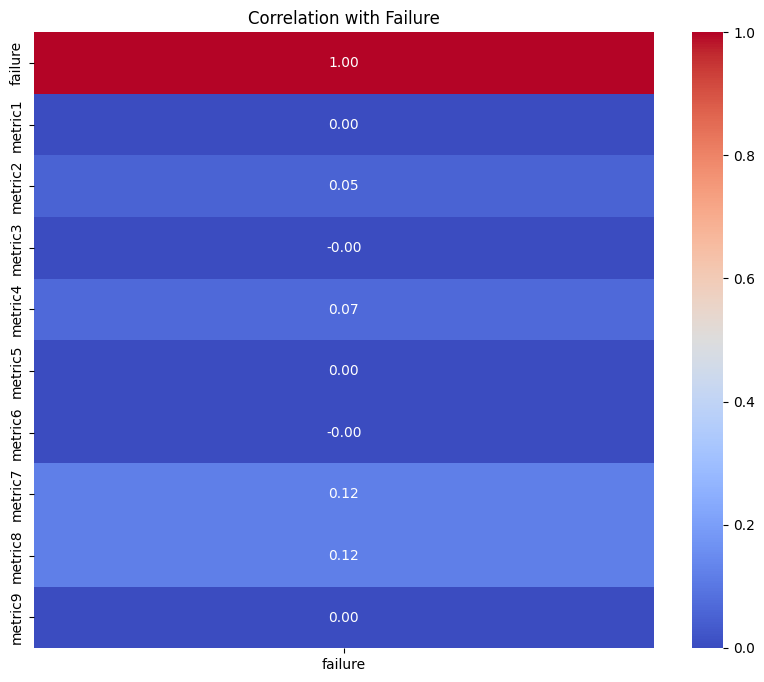

Correlation of metrics with failure:
failure    1.000000
metric8    0.119055
metric7    0.119055
metric4    0.067398
metric2    0.052901
metric5    0.002270
metric1    0.001983
metric9    0.001067
metric6   -0.000550
metric3   -0.000948
Name: failure, dtype: float64


In [10]:
# Select only numerical columns for correlation calculation
numerical_df_2 = df_2.select_dtypes(include=np.number)

# Calculate the correlation matrix
correlation_matrix = numerical_df_2.corr()

# Extract the correlation with the 'failure' column
failure_correlation = correlation_matrix['failure'].sort_values(ascending=False)

# Visualize the correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix[['failure']], annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation with Failure')
plt.show()

print("Correlation of metrics with failure:")
print(failure_correlation)

# **Conclusión en fallos a dispositivos**


*   La causa principial indica ser la falla de componentes físicos para la caída del sistema.
* Las temperaturas altas demuestran que se pueden presentar afectaciones en el servicio
* El VOC y el AQ son los componentes de las máquinas son el componente al que más atención se le debería poner



# **Modelo predictivo para predecir fallas**

Separar los datos de Train y Test, la variable a predecir es que fallen los dispositivos

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar dataset
df = df_2.copy()  # Usa tu dataframe principal
df = df.dropna(subset=['failure'])  # Eliminar filas sin etiqueta

# Seleccionar características
features = [c for c in df.columns if c.startswith('metric')]
X = df[features]
y = df['failure']

# Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# División en entrenamiento y prueba (estratificada)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Tamaño de entrenamiento: {X_train.shape[0]}")
print(f"Tamaño de prueba: {X_test.shape[0]}")


Tamaño de entrenamiento: 99595
Tamaño de prueba: 24899


Modelo de regresión logística

=== Regresión Logística ===
              precision    recall  f1-score   support

           0       1.00      0.95      0.97     24878
           1       0.01      0.48      0.02        21

    accuracy                           0.95     24899
   macro avg       0.50      0.71      0.49     24899
weighted avg       1.00      0.95      0.97     24899

ROC-AUC: 0.741


/tmp/ipython-input-3252742110.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coef.values, y=coef.index, palette="coolwarm")


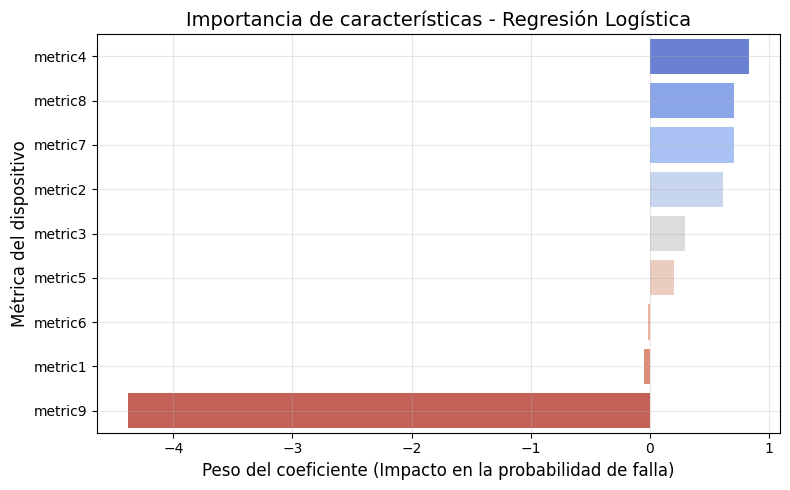

In [14]:
log_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

print("=== Regresión Logística ===")
print(classification_report(y_test, y_pred_log))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_log):.3f}")

# Importancia de variables
coef = pd.Series(log_model.coef_[0], index=features).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=coef.values, y=coef.index, palette="coolwarm")
plt.title("Importancia de características - Regresión Logística", fontsize=14)
plt.xlabel("Peso del coeficiente (Impacto en la probabilidad de falla)", fontsize=12)
plt.ylabel("Métrica del dispositivo", fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


En el dispositivo 4 es más posible que se presente la falla según los datos técnicos.

## Crear la matriz de confusión

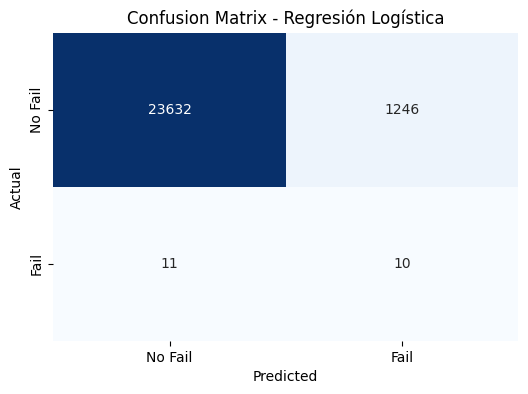

In [16]:
cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Regresión Logística')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks([0.5, 1.5], ['No Fail', 'Fail'])
plt.yticks([0.5, 1.5], ['No Fail', 'Fail'])
plt.show()

- Tenemos alto número de acierto, predice bien las variables positivas del sistema.
- Hay una cantidad alta en la predicción de falsos positivos
- Detecta menos de los casos reales.

In [18]:
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [19]:
sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)

print(f"Tamaño original del entrenamiento: {len(y_train)}")
print(f"Tamaño balanceado del entrenamiento: {len(y_train_bal)}")
print(f"Proporción de clases balanceadas: {y_train_bal.value_counts().to_dict()}")

Tamaño original del entrenamiento: 99595
Tamaño balanceado del entrenamiento: 199020
Proporción de clases balanceadas: {0: 99510, 1: 99510}


In [21]:
#Balancear al train
sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)

print(f"Tamaño original del entrenamiento: {len(y_train)}")
print(f"Tamaño balanceado del entrenamiento: {len(y_train_bal)}")
print(f"Proporción de clases balanceadas: {y_train_bal.value_counts().to_dict()}")

Tamaño original del entrenamiento: 99595
Tamaño balanceado del entrenamiento: 199020
Proporción de clases balanceadas: {0: 99510, 1: 99510}


## Reentrenar el modelo

In [22]:
log_model_bal = LogisticRegression(max_iter=1000, random_state=42)
log_model_bal.fit(X_train_bal, y_train_bal)

# Predicciones
y_pred_bal = log_model_bal.predict(X_test)
y_prob_bal = log_model_bal.predict_proba(X_test)[:, 1]

# Métricas
print("=== Regresión Logística Balanceada (SMOTE) ===")
print(classification_report(y_test, y_pred_bal))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_bal):.3f}")

=== Regresión Logística Balanceada (SMOTE) ===
              precision    recall  f1-score   support

           0       1.00      0.97      0.98     24878
           1       0.01      0.48      0.02        21

    accuracy                           0.97     24899
   macro avg       0.51      0.72      0.50     24899
weighted avg       1.00      0.97      0.98     24899

ROC-AUC: 0.785


## Matriz de confusión

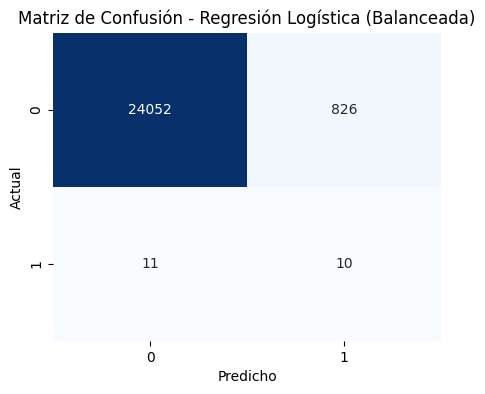

In [23]:
cm_bal = confusion_matrix(y_test, y_pred_bal)
plt.figure(figsize=(5,4))
sns.heatmap(cm_bal, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Matriz de Confusión - Regresión Logística (Balanceada)")
plt.xlabel("Predicho")
plt.ylabel("Actual")
plt.show()

Ahora se detectan más fallas reales